# 02 — XAI and newly trained contiguous partial-cycle models

This notebook reuses the exact sensor-7 model and 40-UGM adaptation subset from Notebook 01.

First, occlusion measures which high/low pair matters most. Then a **nested contiguous window** grows from that pair by adding one adjacent pair at a time. A new transfer model is trained for every window. This directly answers how well a model can work with only one continuous part of the measurement cycle.

In [1]:
from pathlib import Path
import sys, json, numpy as np, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents)
          if (p/"Networks"/"TCOCNNv3.py").exists())
sys.path[:0]=[str(ROOT/"Networks"),str(ROOT/"Evaluation Seminar"/"Day_03"),
              str(ROOT/"Evaluation Seminar"/"Day_04")]
from day4_utils import (load_checkpoint,load_sensor_domains,scale_domain,
                        predict_ppb,fit_network)
from transfer_workflow import group_values,metrics,copy_state,save_json

OUTPUT=ROOT/"artifacts"/"seminar_day4_transfer"
model,scaler,metadata=load_checkpoint(OUTPUT/"target_finetuned")
source_model,_,source_metadata=load_checkpoint(
    ROOT/"artifacts"/"seminar_day4_global6_hpo"/"source_global6_hpo")
config=json.loads((OUTPUT/"transfer_config.json").read_text())
raw,_=load_sensor_domains(channel=0,calibration=1,gas="acetone")
target=config["target"]; domain=scale_domain(raw[target],scaler)
selected=np.isin(domain["train"]["groups"],config["selected_groups"])
adaptation={key:value[selected] for key,value in domain["train"].items()}
LR=config["selected_learning_rate"]; EPOCHS=config["fine_tune_epochs"]
print("Target:",target,"| reused UGMs:",len(np.unique(adaptation["groups"])))
print("Partial-model transfer settings: LR",LR,"| epochs",EPOCHS,
      "| subsensor",config["channel"])

Target: 84749569 | reused UGMs: 40
Partial-model transfer settings: LR 3e-07 | epochs 5 | subsensor 0


## The real sensor-7 cycles used in both notebooks

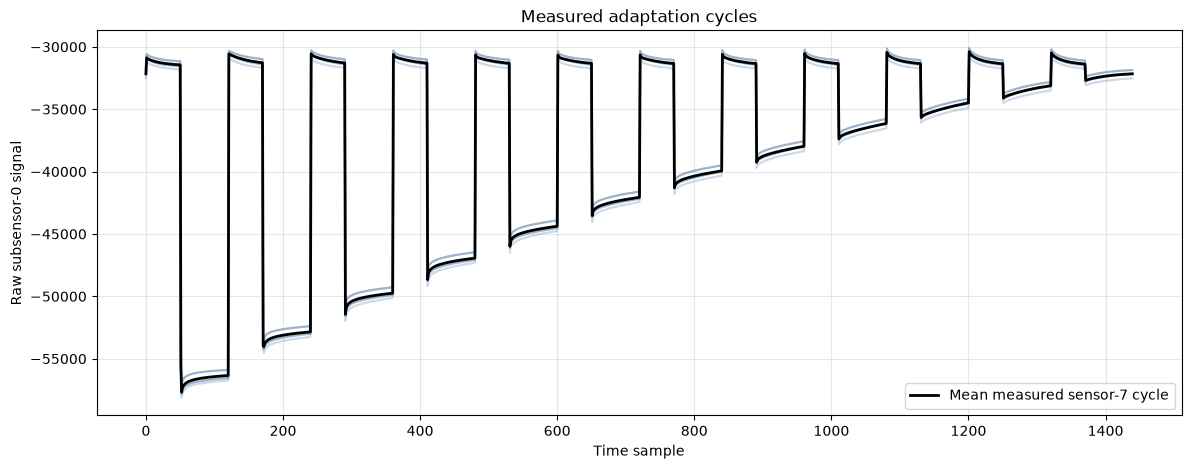

In [2]:
raw_cycles=adaptation["X"][:,0,:,0]
fig,ax=plt.subplots(figsize=(14,5))
for cycle in raw_cycles[:12]: ax.plot(cycle,color="#4c78a8",alpha=.15)
ax.plot(raw_cycles.mean(0),color="black",lw=2,label="Mean measured sensor-7 cycle")
ax.set(title="Measured adaptation cycles",xlabel="Time sample",
       ylabel="Raw subsensor-0 signal")
ax.legend(); ax.grid(True,alpha=.3); plt.show()

## Occlusion and one scatter per held-out pair

Each of the 12 physical parts contains 50 high-temperature and 70 low-temperature samples. Importance is measured on adaptation data; scatter plots use validation UGMs.

In [3]:
PAIR=120; N_PAIRS=adaptation["X_z"].shape[2]//PAIR
reference=adaptation["X_z"].mean(0,keepdims=True)
baseline=predict_ppb(model,adaptation,scaler)
effects=[]
for pair in range(N_PAIRS):
    held=adaptation["X_z"].copy()
    held[:,:,pair*PAIR:(pair+1)*PAIR,:]=reference[:,:,pair*PAIR:(pair+1)*PAIR,:]
    effects.append(baseline-predict_ppb(model,{"X_z":held},scaler))
effects=np.stack(effects,axis=1)
importance=np.asarray([
    np.mean([np.abs(effects[adaptation["groups"]==group,pair]).mean()
             for group in np.unique(adaptation["groups"])])
    for pair in range(N_PAIRS)])
start_pair=int(np.argmax(importance))

occlusion_rows=[]; scatter_values=[]
for pair in range(N_PAIRS):
    held=domain["val"]["X_z"].copy()
    held[:,:,pair*PAIR:(pair+1)*PAIR,:]=reference[:,:,pair*PAIR:(pair+1)*PAIR,:]
    pred=predict_ppb(model,{"X_z":held},scaler)
    occlusion_rows.append({"held_out_pair":pair+1,
                           **metrics(domain["val"]["y"],pred,
                                     domain["val"]["groups"])})
    scatter_values.append(group_values(domain["val"]["y"],pred,
                                       domain["val"]["groups"]))
print("Most important starting pair:",start_pair+1)

Most important starting pair: 1


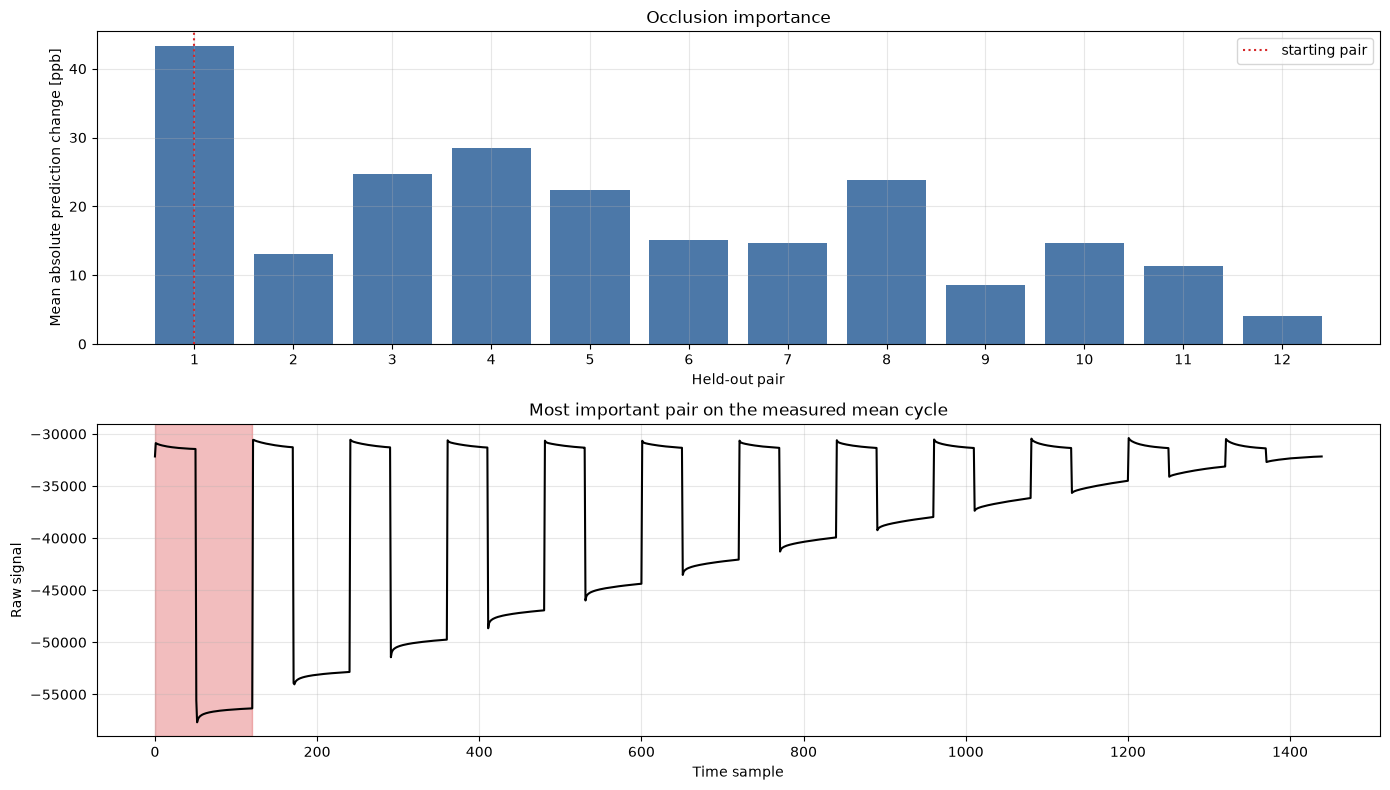

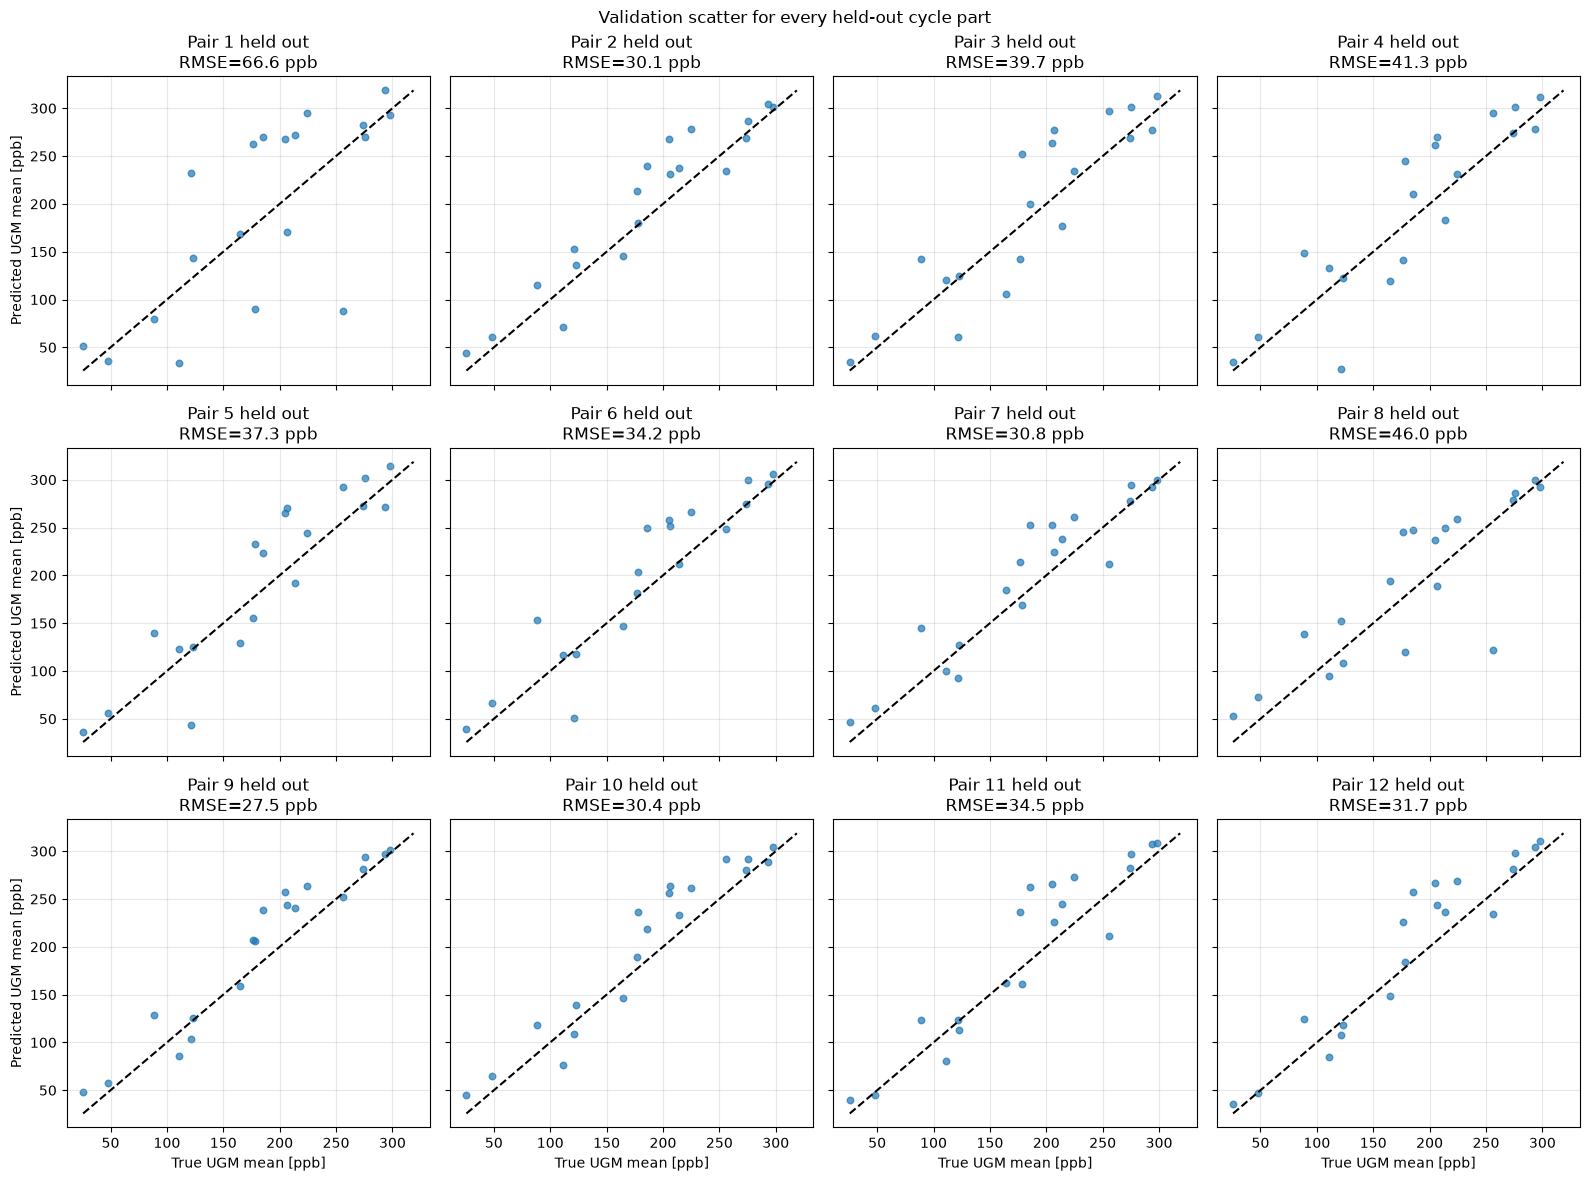

In [4]:
fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].bar(np.arange(1,N_PAIRS+1),importance,color="#4c78a8")
axes[0].axvline(start_pair+1,color="#d62728",ls=":",label="starting pair")
axes[0].set(title="Occlusion importance",xlabel="Held-out pair",
            ylabel="Mean absolute prediction change [ppb]",
            xticks=np.arange(1,N_PAIRS+1)); axes[0].legend()
axes[1].plot(raw_cycles.mean(0),color="black")
axes[1].axvspan(start_pair*PAIR,(start_pair+1)*PAIR,color="#d62728",alpha=.3)
axes[1].set(title="Most important pair on the measured mean cycle",
            xlabel="Time sample",ylabel="Raw signal")
for ax in axes: ax.grid(True,alpha=.3)
plt.tight_layout(); plt.show()

lo=min(min(a.min(),b.min()) for a,b in scatter_values)
hi=max(max(a.max(),b.max()) for a,b in scatter_values)
fig,axes=plt.subplots(3,4,figsize=(16,12),sharex=True,sharey=True)
for pair,ax in enumerate(axes.ravel()):
    truth,pred=scatter_values[pair]
    ax.scatter(truth,pred,s=22,alpha=.7); ax.plot([lo,hi],[lo,hi],"k--")
    ax.set(title=f"Pair {pair+1} held out\n"
                 f"RMSE={occlusion_rows[pair]['UGM_RMSE_ppb']:.1f} ppb")
    ax.grid(True,alpha=.3)
for ax in axes[-1]: ax.set_xlabel("True UGM mean [ppb]")
for ax in axes[:,0]: ax.set_ylabel("Predicted UGM mean [ppb]")
fig.suptitle("Validation scatter for every held-out cycle part")
plt.tight_layout(); plt.show()

## Build one nested, contiguous window

The first window is the most important pair. At each step, only its immediate left or right neighbor may be added. The neighbor with the larger occlusion importance is chosen. Thus every larger input contains the complete previous input and never becomes fragmented.

[{'retained_pairs': 1, 'first_pair': 1, 'last_pair': 1, 'samples': 120}, {'retained_pairs': 2, 'first_pair': 1, 'last_pair': 2, 'samples': 240}, {'retained_pairs': 3, 'first_pair': 1, 'last_pair': 3, 'samples': 360}, {'retained_pairs': 4, 'first_pair': 1, 'last_pair': 4, 'samples': 480}, {'retained_pairs': 5, 'first_pair': 1, 'last_pair': 5, 'samples': 600}, {'retained_pairs': 6, 'first_pair': 1, 'last_pair': 6, 'samples': 720}, {'retained_pairs': 7, 'first_pair': 1, 'last_pair': 7, 'samples': 840}, {'retained_pairs': 8, 'first_pair': 1, 'last_pair': 8, 'samples': 960}, {'retained_pairs': 9, 'first_pair': 1, 'last_pair': 9, 'samples': 1080}, {'retained_pairs': 10, 'first_pair': 1, 'last_pair': 10, 'samples': 1200}, {'retained_pairs': 11, 'first_pair': 1, 'last_pair': 11, 'samples': 1320}, {'retained_pairs': 12, 'first_pair': 1, 'last_pair': 12, 'samples': 1440}]


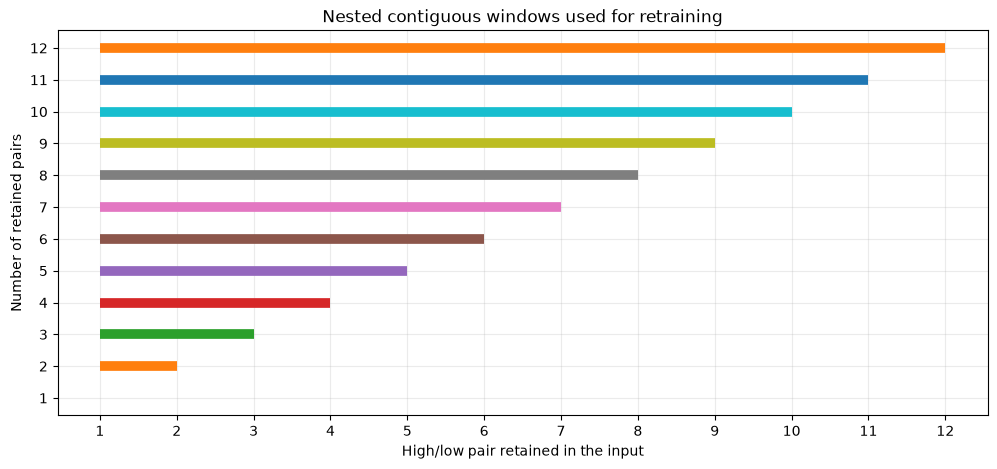

In [5]:
windows=[(start_pair,start_pair)]
left=right=start_pair
while right-left+1<N_PAIRS:
    options=[]
    if left>0: options.append((importance[left-1],left-1,"left"))
    if right<N_PAIRS-1: options.append((importance[right+1],right+1,"right"))
    _,pair,direction=max(options,key=lambda item:item[0])
    if direction=="left": left=pair
    else: right=pair
    windows.append((left,right))

window_rows=[{"retained_pairs":i+1,"first_pair":left+1,"last_pair":right+1,
              "samples":(right-left+1)*PAIR}
             for i,(left,right) in enumerate(windows)]
try:
    import pandas as pd
    display(pd.DataFrame(window_rows))
except ImportError:
    print(window_rows)

fig,ax=plt.subplots(figsize=(12,5))
for row,(left,right) in enumerate(windows):
    ax.plot([left+1,right+1],[row+1,row+1],lw=7,solid_capstyle="butt")
ax.set(title="Nested contiguous windows used for retraining",
       xlabel="High/low pair retained in the input",
       ylabel="Number of retained pairs",
       xticks=np.arange(1,N_PAIRS+1),yticks=np.arange(1,N_PAIRS+1))
ax.grid(True,alpha=.25); plt.show()

## Train a new model for every contiguous window

Every model starts from the same saved Global-6 weights and uses the transfer learning rate and epoch count selected on sensor 6. Only the contiguous input length changes. Validation and test are never used for fitting.

In [6]:
partial_rows=[]; partial_predictions={}; partial_models={}
params={**source_metadata["params"],"initial_learning_rate":LR}
for count,(left,right) in enumerate(windows,1):
    begin,end=left*PAIR,(right+1)*PAIR
    reduced={}
    for split in ["train","val","test"]:
        original=adaptation if split=="train" else domain[split]
        reduced[split]={**original,"X_z":original["X_z"][:,:,begin:end,:]}
    partial,history,_=fit_network(
        reduced,params,epochs=EPOCHS,initial=copy_state(source_model),
        freeze_batchnorm=True,restore_best=False,use_validation=False,
        lr_schedule="constant",seed=config.get("seed",42),verbose=False)
    partial_models[count]=partial
    for split in ["val","test"]:
        pred=predict_ppb(partial,reduced[split],scaler)
        partial_predictions[(count,split)]=pred
        partial_rows.append({"split":split,"retained_pairs":count,
                             "first_pair":left+1,"last_pair":right+1,
                             "samples":end-begin,
                             "seconds_at_10_Hz":(end-begin)/10,
                             **metrics(domain[split]["y"],pred,
                                       domain[split]["groups"])})
    print(f"Trained {count:2d}/{N_PAIRS}: pairs {left+1}-{right+1}, "
          f"{end-begin} contiguous samples")

Trained  1/12: pairs 1-1, 120 contiguous samples
Trained  2/12: pairs 1-2, 240 contiguous samples
Trained  3/12: pairs 1-3, 360 contiguous samples
Trained  4/12: pairs 1-4, 480 contiguous samples
Trained  5/12: pairs 1-5, 600 contiguous samples
Trained  6/12: pairs 1-6, 720 contiguous samples
Trained  7/12: pairs 1-7, 840 contiguous samples
Trained  8/12: pairs 1-8, 960 contiguous samples
Trained  9/12: pairs 1-9, 1080 contiguous samples
Trained 10/12: pairs 1-10, 1200 contiguous samples
Trained 11/12: pairs 1-11, 1320 contiguous samples
Trained 12/12: pairs 1-12, 1440 contiguous samples


## How much continuous cycle does the model need?

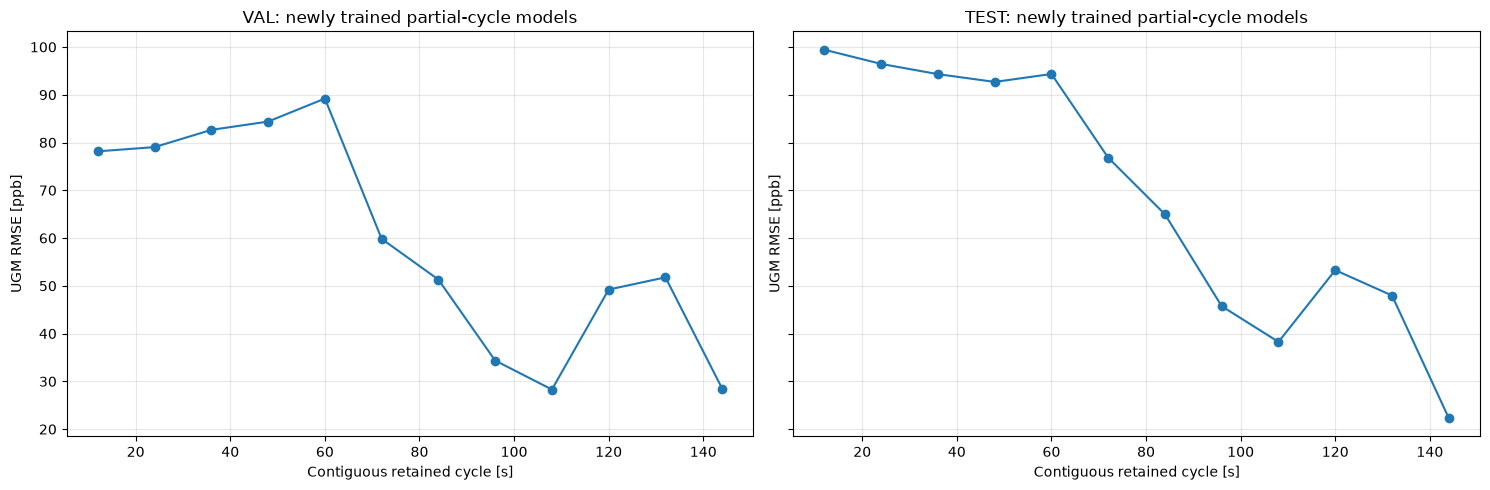

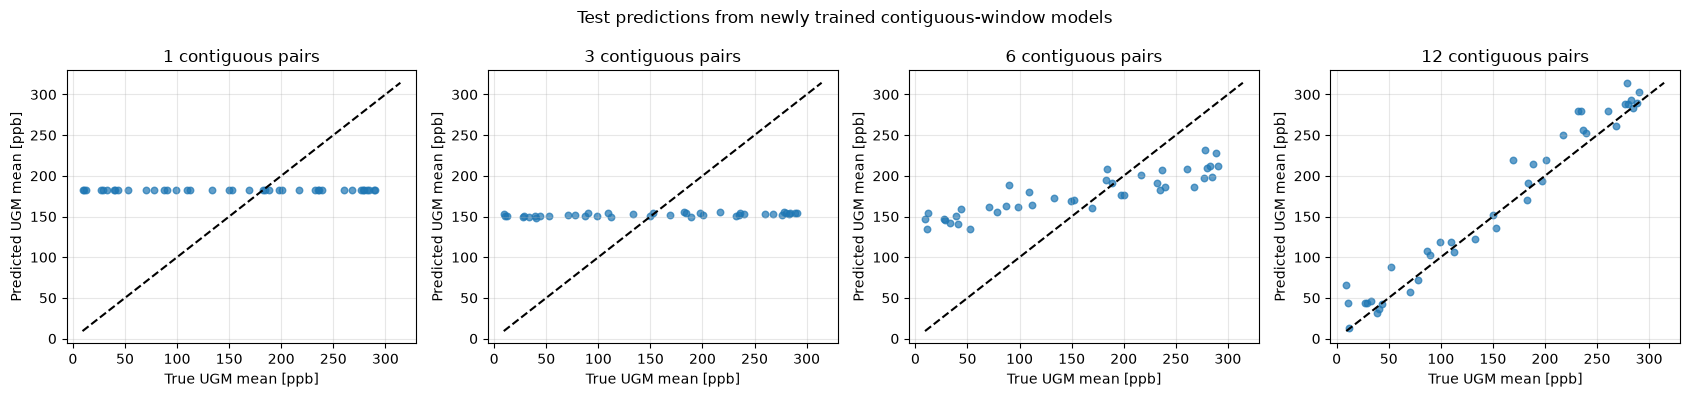

Saved XAI output: \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_transfer\xai_occlusion.json


In [7]:
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True)
for ax,split in zip(axes,["val","test"]):
    rows=[row for row in partial_rows if row["split"]==split]
    ax.plot([row["seconds_at_10_Hz"] for row in rows],
            [row["UGM_RMSE_ppb"] for row in rows],marker="o")
    ax.set(title=f"{split.upper()}: newly trained partial-cycle models",
           xlabel="Contiguous retained cycle [s]",ylabel="UGM RMSE [ppb]")
    ax.grid(True,alpha=.3)
plt.tight_layout(); plt.show()

selected_counts=sorted(set([1,3,6,N_PAIRS]))
vals={f"{count} contiguous pairs":partial_predictions[(count,"test")]
      for count in selected_counts}
truth_groups=domain["test"]["groups"]
grouped={name:group_values(domain["test"]["y"],pred,truth_groups)
         for name,pred in vals.items()}
lo=min(min(a.min(),b.min()) for a,b in grouped.values())
hi=max(max(a.max(),b.max()) for a,b in grouped.values())
fig,axes=plt.subplots(1,len(grouped),figsize=(17,4))
for ax,(name,(truth,pred)) in zip(axes,grouped.items()):
    ax.scatter(truth,pred,s=22,alpha=.7); ax.plot([lo,hi],[lo,hi],"k--")
    ax.set(title=name,xlabel="True UGM mean [ppb]",
           ylabel="Predicted UGM mean [ppb]"); ax.grid(True,alpha=.3)
fig.suptitle("Test predictions from newly trained contiguous-window models")
plt.tight_layout(); plt.show()

save_json(OUTPUT/"xai_occlusion.json",
          {"starting_pair_one_based":start_pair+1,
           "occlusion":occlusion_rows,"windows":window_rows,
           "partial_model_results":partial_rows})
print("Saved XAI output:",OUTPUT/"xai_occlusion.json")